# 08 - Explicabilidad de los modelos candidatos

Este notebook realiza la auditoría explicativa de los modelos candidatos sobre el conjunto de validación de 2024. La finalidad no es seleccionar el modelo ganador a partir de la elaboración de una puntuación numérica obtenida mediantes técnicas de XAI: es comprobar que no se den anomalías en la importancia de las variables consideradas.

Se analizan los cuatro candidatos:

- Modelo base ingenuo estacional: se explicará mediante su regla de persistencia diaria.
- Regresión lineal cuantílica: se realizará una interpretación de los coeficientes estandarizados del cuantil central central.
- LightGBM: se efectuará una explicación mediante contribuciones SHAP.
- CatBoost: se efectuará una explicación mediante contribuciones SHAP.


## Papel de la explicabilidad en la selección

La explicabilidad se tratará como un criterio de admisibilidad. En términos metodológicos, la selección posterior podría, por ejemplo, expresarse como:

$$
m^* = \arg\min_{m \in \mathcal{M}_{adm}} J(m),
$$

donde:

$$
\mathcal{M}_{adm} = \{m \in \mathcal{M}: E(m)=1\}.
$$

Es decir, $E(m)=1$ significa que el análisis explicativo sobre el conjunto de validación no revela importancias anómalas de las variales predictivas.


In [1]:
from __future__ import annotations

import json
import warnings
from pathlib import Path
from typing import Any, Dict, Iterable, Sequence

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

try:
    from catboost import Pool
except ImportError as exc:
    raise ImportError(
        "Este notebook requiere utilizar CatBoost para el cálculo de las contribuciones SHAP nativas."
    ) from exc

pd.set_option("display.max_columns", 160)
pd.set_option("display.max_rows", 120)
pd.set_option("display.width", 180)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")


In [2]:
# Configuración general del notebook
# ==============================================================================
# El notebook puede ejecutarse desde la carpeta notebooks/ o desde la raíz del
# repositorio. Esta función localiza la raíz de forma dinámica.

def find_project_root(start: Path | None = None) -> Path:
    """Busca la raíz del proyecto partiendo del directorio actual.

    Esta función evita depender de rutas absolutas locales. Así, el notebook puede
    ejecutarse aunque el repositorio esté guardado en otra carpeta o se abra desde
    un directorio diferente dentro del proyecto.
    """
    current = Path.cwd() if start is None else start.resolve()

    for candidate in [current, *current.parents]:
        if (candidate / "data").exists() and (candidate / "reports").exists():
            return candidate

    raise FileNotFoundError(
        "No se pudo localizar la raíz del proyecto. Debe ejecutarse el notebook desde "
        "la raíz del repositorio o desde la carpeta notebooks/."
    )


PROJECT_ROOT = find_project_root()

DATA_MODELING_DIR = PROJECT_ROOT / "data" / "modeling"
MODELS_DIR = PROJECT_ROOT / "models"
MODELS_CQR_DIR = MODELS_DIR / "cqr_mapie"
REPORTS_TABLES_DIR = PROJECT_ROOT / "reports" / "tables"
REPORTS_FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"

for directory in [REPORTS_TABLES_DIR, REPORTS_FIGURES_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

HORIZONS: list[int] = [1, 4, 12, 24]
VALIDATION_SPLIT = "validation"
RANDOM_STATE = 42

SHAP_SAMPLE_SIZE = 2500

MODEL_REGISTRY: dict[str, dict[str, str]] = {
    "baseline_seasonal_naive": {
        "display_name": "Modelo base ingenuo estacional",
        "short_name": "Base",
        "technique": "Regla explícita",
        "point_model_path": "",
    },
    "linear_regression": {
        "display_name": "Regresión lineal",
        "short_name": "Lineal",
        "technique": "Coeficientes estandarizados",
        "point_model_path": "models/linear_regression/linear_regression_h{horizon:02d}.joblib",
    },
    "lightgbm": {
        "display_name": "LightGBM",
        "short_name": "LGBM",
        "technique": "SHAP global",
        "point_model_path": "models/lightgbm/lightgbm_h{horizon:02d}.joblib",
    },
    "catboost": {
        "display_name": "CatBoost",
        "short_name": "CAT",
        "technique": "SHAP global",
        "point_model_path": "models/catboost/catboost_h{horizon:02d}.joblib",
    },
}

MODEL_ORDER = list(MODEL_REGISTRY.keys())
MODEL_ORDER_MAP = {model_id: idx for idx, model_id in enumerate(MODEL_ORDER)}

FAMILY_ORDER = [
    "Memoria reciente",
    "Persistencia diaria",
    "Ventanas móviles",
    "Calendario horario",
    "Calendario mensual",
    "Calendario semanal",
    "Calidad de ventana",
    "Otros",
]

plt.rcParams.update(
    {
        "figure.dpi": 120,
        "savefig.dpi": 300,
        "axes.titlesize": 12,
        "axes.labelsize": 11,
        "legend.fontsize": 10,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
    }
)

print(f"Raíz del proyecto: {PROJECT_ROOT}")
print(f"Datasets de modelado: {DATA_MODELING_DIR}")
print(f"Modelos CQR/MAPIE: {MODELS_CQR_DIR}")
print(f"Tablas: {REPORTS_TABLES_DIR}")
print(f"Figuras: {REPORTS_FIGURES_DIR}")
print(f"Split explicativo: {VALIDATION_SPLIT} (2024)")


Raíz del proyecto: c:\trabajo_github
Datasets de modelado: c:\trabajo_github\data\modeling
Modelos CQR/MAPIE: c:\trabajo_github\models\cqr_mapie
Tablas: c:\trabajo_github\reports\tables
Figuras: c:\trabajo_github\reports\figures
Split explicativo: validation (2024)


## Carga de las variables predictoras y de los conjuntos de datos

A continuación, se cargará cada conjunto de datos generado por los notebooks anteriores para cada horizonte. La auditoría, como ya se ha mencionado, se realizará exclusivamente sobre la partición de validación.


In [3]:
FEATURE_COLUMNS_PATH = DATA_MODELING_DIR / "feature_columns.json"

if not FEATURE_COLUMNS_PATH.exists():
    raise FileNotFoundError(
        "No se ha encontrado el archivo data/modeling/feature_columns.json. "
        "Deberá ejecutarse en primer lugar el notebook 02_modeling_dataset_features."
    )

feature_payload = json.loads(FEATURE_COLUMNS_PATH.read_text(encoding="utf-8"))
feature_columns_by_horizon: dict[str, list[str]] = feature_payload.get("feature_columns_by_horizon", {})
default_feature_columns: list[str] = feature_payload.get("feature_columns", [])

if not feature_columns_by_horizon and not default_feature_columns:
    raise ValueError("El archivo feature_columns.json no contiene variables predictoras.")


def get_feature_columns(horizon: int) -> list[str]:
    """Devuelve las variables predictoras correspondientes a un horizonte."""
    feature_columns = feature_columns_by_horizon.get(str(horizon), default_feature_columns)
    if not feature_columns:
        raise ValueError(f"No se encontraron variables predictoras para h={horizon}.")
    return feature_columns


def load_modeling_dataset(horizon: int) -> pd.DataFrame:
    """Carga el conjunto de datos de modelado de un horizonte concreto."""
    path = DATA_MODELING_DIR / f"modeling_h{horizon:02d}.parquet"
    if not path.exists():
        raise FileNotFoundError(
            f"No se ha encontrado {path}. Deberá ejecutarse primero el notebook 02_modeling_dataset_features."
        )

    df = pd.read_parquet(path).copy()
    for col in ["origin_timestamp", "target_timestamp"]:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col])
    return df.sort_values("target_timestamp").reset_index(drop=True)


datasets_by_horizon: dict[int, pd.DataFrame] = {h: load_modeling_dataset(h) for h in HORIZONS}

dataset_overview_rows = []
for horizon, df in datasets_by_horizon.items():
    feature_columns = get_feature_columns(horizon)
    validation_df = df.loc[df["split"] == VALIDATION_SPLIT].copy()
    dataset_overview_rows.append(
        {
            "horizon": horizon,
            "n_rows_total": len(df),
            "n_validation": len(validation_df),
            "n_features": len(feature_columns),
            "validation_start": validation_df["target_timestamp"].min(),
            "validation_end": validation_df["target_timestamp"].max(),
            "validation_missing_y": int(validation_df["y"].isna().sum()),
        }
    )

dataset_overview_df = pd.DataFrame(dataset_overview_rows)
display(dataset_overview_df)


,horizon,n_rows_total,n_validation,n_features,validation_start,validation_end,validation_missing_y
0,1,50941,8437,21,2024-01-01,2024-12-31 23:00:00,0
1,4,50938,8437,21,2024-01-01,2024-12-31 23:00:00,0
2,12,50930,8437,20,2024-01-01,2024-12-31 23:00:00,0
3,24,50918,8437,20,2024-01-01,2024-12-31 23:00:00,0


## Funciones auxiliares

Se define, a continuación, una serie de funciones auxiliares que facilitarán clasificar las variables por familias, cargar los modelos, extraer los coeficientes y calcular las contribuciones SHAP mediante las implementaciones nativas de LightGBM y CatBoost.


In [4]:
def feature_family(feature: str) -> str:
    """Clasifica una variable predictora dentro de una familia."""
    if feature in {"o3_at_origin", "o3_lag_1h", "o3_lag_2h", "o3_lag_3h", "o3_lag_6h", "o3_lag_12h"}:
        return "Memoria reciente"
    if feature in {"o3_prev_day_same_hour", "o3_target_lag_48h"}:
        return "Persistencia diaria"
    if feature.startswith("o3_roll_missing"):
        return "Calidad de ventana"
    if feature.startswith("o3_roll_"):
        return "Ventanas móviles"
    if feature.startswith("target_hour"):
        return "Calendario horario"
    if feature.startswith("target_month"):
        return "Calendario mensual"
    if feature.startswith("target_dayofweek") or feature == "target_is_weekend":
        return "Calendario semanal"
    return "Otros"


def validation_sample_for_xai(
    df: pd.DataFrame,
    feature_columns: Sequence[str],
    sample_size: int - None = SHAP_SAMPLE_SIZE,
) -> tuple[pd.DataFrame, pd.Series, pd.DataFrame]:
    
    validation_df = df.loc[df["split"] == VALIDATION_SPLIT].dropna(subset=["y"]).copy()
    validation_df = validation_df.sort_values("target_timestamp").reset_index(drop=True)

    if validation_df.empty:
        raise ValueError("El conjunto de validación está vacío.")

    missing_features = [feature for feature in feature_columns if feature not in validation_df.columns]
    if missing_features:
        raise KeyError(f"Faltan variables predictoras en el conjunto de validación: {missing_features}")

    if sample_size is not None and len(validation_df) > sample_size:
        # Muestra sistemática: conserva observaciones repartidas a lo largo de todo el año.
        selected_idx = np.linspace(0, len(validation_df) - 1, sample_size, dtype=int)
        selected_idx = np.unique(selected_idx)
        validation_df = validation_df.iloc[selected_idx].copy().reset_index(drop=True)

    X = validation_df.loc[:, list(feature_columns)].copy()
    y = validation_df["y"].copy()
    metadata = validation_df[["horizon", "split", "origin_timestamp", "target_timestamp"]].copy()

    return X, y, metadata


def relative_to_project(path: Path) -> str:
    """Devuelve una ruta relativa a la raíz del proyecto si es posible."""
    try:
        return str(path.relative_to(PROJECT_ROOT))
    except ValueError:
        return str(path)


def quantile_model_candidates(model_id: str, horizon: int) -> list[tuple[Path, str]]:
    """Devuelve los modelos cuantílicos generados por el notebook 06b_cqr_supervised_models."""
    candidates: list[tuple[Path, str]] = []

    if model_id in {"linear_regression", "lightgbm"}:
        path = MODELS_CQR_DIR / f"cqr_mapie_{model_id}_h{horizon:02d}_median.joblib"
        candidates.append((path, "cqr_median_q0.50"))
    elif model_id == "catboost":
        # CatBoost se entrenó como MultiQuantile. El componente q0.50 se extrae
        # posteriormente de las contribuciones SHAP multi-salida.
        path = MODELS_CQR_DIR / f"cqr_mapie_{model_id}_h{horizon:02d}_multiquantile.joblib"
        candidates.append((path, "cqr_multiquantile_q0.50_component"))

    return candidates


def point_model_candidate(model_id: str, horizon: int) -> tuple[Path, str]:
    """Devuelve el modelo puntual entrenado en los notebooks 04a-04c."""
    template = MODEL_REGISTRY[model_id]["point_model_path"]
    path = PROJECT_ROOT / template.format(horizon=horizon)
    return path, "point_model_fallback"


def load_xai_model(model_id: str, horizon: int) -> tuple[Any, dict[str, Any]]:
    """Carga el modelo que se utilizará para la explicación."""
    if model_id == "baseline_seasonal_naive":
        raise ValueError("El modelo base se explica mediante su regla de persistencia.")

    # Se prioriza la versión cuantílica central. Si por lo que fuere no estuviera disponible,
    # se recurrirá al modelo puntual
    candidates = quantile_model_candidates(model_id, horizon)
    candidates.append(point_model_candidate(model_id, horizon))

    tried_paths = []
    for path, source in candidates:
        tried_paths.append(path)
        if path.exists():
            model = joblib.load(path)
            return model, {
                "model": model_id,
                "horizon": horizon,
                "model_source": source,
                "model_path": relative_to_project(path),
            }

    raise FileNotFoundError(
        f"No se encontró ningún modelo para {model_id}, h={horizon}. "
        f"Rutas probadas: {[str(path) for path in tried_paths]}"
    )

def extract_linear_coefficients(model: Any, feature_columns: Sequence[str]) -> tuple[np.ndarray, str]:
    """Extrae los coeficientes de la regresión cuantílica (o lineal si no estuvieran disponibles los modelos cuantílicos)."""
    estimator = None
    estimator_name = "unknown"

    if hasattr(model, "named_steps"):
        for step_name, step in model.named_steps.items():
            if hasattr(step, "coef_"):
                estimator = step
                estimator_name = step_name
                break
    elif hasattr(model, "coef_"):
        estimator = model
        estimator_name = model.__class__.__name__

    if estimator is None:
        raise TypeError(
            "No se han podido extraer los coeficientes del modelo. "
            f"El tipo de modelo recibido fue: {type(model)}"
        )

    coefficients = np.asarray(estimator.coef_, dtype=float).ravel()
    if len(coefficients) != len(feature_columns):
        raise ValueError(
            f"El número de coeficientes ({len(coefficients)}) es distinto del número de características ({len(feature_columns)})."
        )

    return coefficients, estimator_name

def extract_feature_shap_array(
    raw_values: np.ndarray,
    n_features: int,
    preferred_output_index: int | None = None,
) -> np.ndarray:
    """Extrae la matriz (n_observaciones, n_features) de valores SHAP."""
    arr = np.asarray(raw_values, dtype=float)

    if arr.ndim == 2:
        if arr.shape[1] == n_features + 1:
            return arr[:, :-1]
        if arr.shape[1] == n_features:
            return arr

    if arr.ndim == 3:
        output_index = 0 if preferred_output_index is None else preferred_output_index

        if arr.shape[1] == n_features + 1:
            output_index = min(output_index, arr.shape[2] - 1)
            return arr[:, :-1, output_index]

        if arr.shape[2] == n_features + 1:
            output_index = min(output_index, arr.shape[1] - 1)
            return arr[:, output_index, :-1]

        if arr.shape[2] == n_features + 1 and arr.shape[0] <= 5:
            output_index = min(output_index, arr.shape[0] - 1)
            return arr[output_index, :, :-1]

    raise ValueError(
        f"No se pudo interpretar la forma de la matriz SHAP: {arr.shape} para {n_features} variables."
    )


def compute_lightgbm_shap_values(model: Any, X: pd.DataFrame) -> np.ndarray:
    """Calcula las contribuciones SHAP de LightGBM mediante pred_contrib."""
    try:
        raw_values = model.predict(X, pred_contrib=True)
    except TypeError:
        raw_values = model.booster_.predict(X, pred_contrib=True)

    return extract_feature_shap_array(raw_values, n_features=X.shape[1])


def compute_catboost_shap_values(model: Any, X: pd.DataFrame, model_source: str) -> np.ndarray:
    """Calcula las contribuciones SHAP de CatBoost mediante su método nativo."""
    raw_values = model.get_feature_importance(Pool(X), type="ShapValues")

    # Como en el modelo MultiQuantile los cuantiles se entrenaron en el orden
    # q0.10, q0.90, q0.50, el componente central corresponde al índice 2.
    preferred_output_index = 2 if "multiquantile" in model_source else None
    return extract_feature_shap_array(
        raw_values,
        n_features=X.shape[1],
        preferred_output_index=preferred_output_index,
    )

def compute_boosting_shap_values(model_id: str, model: Any, X: pd.DataFrame, model_source: str) -> np.ndarray:
    """Calcula SHAP para LightGBM o CatBoost."""
    if model_id == "lightgbm":
        return compute_lightgbm_shap_values(model, X)
    if model_id == "catboost":
        return compute_catboost_shap_values(model, X, model_source)
    raise ValueError(f"No se calcula SHAP para {model_id}.")

def normalize_importance(df: pd.DataFrame) -> pd.DataFrame:
    """Añade importancia relativa dentro de cada pareja modelo-horizonte."""
    out = df.copy()
    totals = out.groupby(["model", "horizon"])["importance_abs"].transform("sum")
    out["importance_relative"] = np.where(totals > 0, out["importance_abs"] / totals, 0.0)
    return out

def save_dataframe_csv(df: pd.DataFrame, path: Path, **kwargs: Any) -> Path:
    """Guarda una tabla CSV y muestra la ruta."""
    path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(path, **kwargs)
    print(f"Tabla guardada: {path}")
    return path

SAVED_FIGURE_PATHS: list[Path] = []

def save_figure(fig: plt.Figure, path: Path, **kwargs: Any) -> Path:
    """Guarda una figura y registra la ruta."""
    path.parent.mkdir(parents=True, exist_ok=True)
    save_kwargs = {"dpi": 300, "bbox_inches": "tight"}
    save_kwargs.update(kwargs)
    fig.savefig(path, **save_kwargs)
    SAVED_FIGURE_PATHS.append(path)
    print(f"Figura guardada: {path}")
    return path


## Explicación del modelo base ingenuo estacional

El modelo base no requiere de una técnica XAI, como se ha explicado. Su predicción se define mediante la siguiente regla de persistencia diaria:

$$
\hat{y}^{base}_{\tau} = y_{\tau - 24}.
$$

Por tanto, su explicación es transparente: para cada instante objetivo, el pronóstico se apoya únicamente en la concentración de $O_3$ registrada en la misma hora del día anterior. Esto no implica que el modelo sea, ni mucho menos, el más útil (como se sabe, es más bien lo contrario), pero sí que proporcionará, como se desea, una referencia interpretativa básica.


In [5]:
feature_importance_rows: list[dict[str, Any]] = []
model_source_rows: list[dict[str, Any]] = []

for horizon in HORIZONS:
    feature_importance_rows.append(
        {
            "model": "baseline_seasonal_naive",
            "model_display": MODEL_REGISTRY["baseline_seasonal_naive"]["display_name"],
            "horizon": horizon,
            "feature": "o3_prev_day_same_hour",
            "family": "Persistencia diaria",
            "importance_abs": 1.0,
            "importance_type": "regla_explicita",
            "model_source": "seasonal_naive_rule",
            "model_path": "no_aplica",
        }
    )
    model_source_rows.append(
        {
            "model": "baseline_seasonal_naive",
            "model_display": MODEL_REGISTRY["baseline_seasonal_naive"]["display_name"],
            "horizon": horizon,
            "technique": MODEL_REGISTRY["baseline_seasonal_naive"]["technique"],
            "model_source": "seasonal_naive_rule",
            "model_path": "no_aplica",
            "n_validation_used": int((datasets_by_horizon[horizon]["split"] == VALIDATION_SPLIT).sum()),
        }
    )

baseline_explanation_df = pd.DataFrame(
    [row for row in feature_importance_rows if row["model"] == "baseline_seasonal_naive"]
)
display(baseline_explanation_df)


,model,model_display,horizon,feature,family,importance_abs,importance_type,model_source,model_path
0,baseline_seasonal_naive,Modelo base ingenuo estacional,1,o3_prev_day_same_hour,Persistencia diaria,1.0000,regla_explicita,seasonal_naive_rule,no_aplica
1,baseline_seasonal_naive,Modelo base ingenuo estacional,4,o3_prev_day_same_hour,Persistencia diaria,1.0000,regla_explicita,seasonal_naive_rule,no_aplica
2,baseline_seasonal_naive,Modelo base ingenuo estacional,12,o3_prev_day_same_hour,Persistencia diaria,1.0000,regla_explicita,seasonal_naive_rule,no_aplica
3,baseline_seasonal_naive,Modelo base ingenuo estacional,24,o3_prev_day_same_hour,Persistencia diaria,1.0000,regla_explicita,seasonal_naive_rule,no_aplica


## Coeficientes de la regresión lineal

La regresión lineal se interpreta a partir de sus coeficientes. Cuando exista el modelo cuantílico central $q_{0,50}$ entrenado en el notebook `06b_cqr_supervised_models`, se utilizará dicha versión. Si no estuviera disponible, se recurrirá al modelo puntual entrenado en el notebook `04a_train_linear_regression`.

In [6]:
linear_coefficient_rows: list[dict[str, Any]] = []

for horizon in HORIZONS:
    model_id = "linear_regression"
    feature_columns = get_feature_columns(horizon)
    model, source_info = load_xai_model(model_id, horizon)
    coefficients, estimator_name = extract_linear_coefficients(model, feature_columns)

    model_source_rows.append(
        {
            "model": model_id,
            "model_display": MODEL_REGISTRY[model_id]["display_name"],
            "horizon": horizon,
            "technique": MODEL_REGISTRY[model_id]["technique"],
            "model_source": source_info["model_source"],
            "model_path": source_info["model_path"],
            "n_validation_used": int((datasets_by_horizon[horizon]["split"] == VALIDATION_SPLIT).sum()),
        }
    )

    for feature, coefficient in zip(feature_columns, coefficients):
        row = {
            "model": model_id,
            "model_display": MODEL_REGISTRY[model_id]["display_name"],
            "horizon": horizon,
            "feature": feature,
            "family": feature_family(feature),
            "coefficient_standardized": float(coefficient),
            "abs_coefficient_standardized": float(abs(coefficient)),
            "importance_abs": float(abs(coefficient)),
            "importance_type": "abs_coeficiente_estandarizado",
            "model_source": source_info["model_source"],
            "model_path": source_info["model_path"],
            "estimator_name": estimator_name,
        }
        linear_coefficient_rows.append(row)
        feature_importance_rows.append(row)

linear_coefficients_df = pd.DataFrame(linear_coefficient_rows)
linear_coefficients_df = normalize_importance(linear_coefficients_df.rename(columns={"abs_coefficient_standardized": "_tmp_abs"})).rename(columns={"_tmp_abs": "abs_coefficient_standardized"})

linear_top_coefficients_df = (
    linear_coefficients_df
    .sort_values(["horizon", "importance_abs"], ascending=[True, False])
    .groupby("horizon")
    .head(10)
    .reset_index(drop=True)
)

display(linear_top_coefficients_df[[
    "horizon",
    "feature",
    "family",
    "coefficient_standardized",
    "importance_relative",
    "model_source",
]])


,horizon,feature,family,coefficient_standardized,importance_relative,model_source
0,1,o3_at_origin,Memoria reciente,27.2306,0.6348,cqr_median_q0.50
1,1,o3_lag_1h,Memoria reciente,-4.4455,0.1036,cqr_median_q0.50
2,1,o3_roll_mean_24h,Ventanas móviles,2.8871,0.0673,cqr_median_q0.50
3,1,o3_roll_mean_6h,Ventanas móviles,-2.0724,0.0483,cqr_median_q0.50
4,1,target_hour_cos,Calendario horario,-1.1198,0.0261,cqr_median_q0.50
5,1,o3_lag_12h,Memoria reciente,-0.8441,0.0197,cqr_median_q0.50
6,1,target_is_weekend,Calendario semanal,0.6492,0.0151,cqr_median_q0.50
7,1,o3_target_lag_48h,Persistencia diaria,0.5648,0.0132,cqr_median_q0.50
8,1,o3_prev_day_same_hour,Persistencia diaria,0.4869,0.0114,cqr_median_q0.50
9,1,o3_roll_max_24h,Ventanas móviles,-0.4325,0.0101,cqr_median_q0.50


Figura guardada: c:\trabajo_github\reports\figures\xai_validation_linear_coefficients_heatmap.png


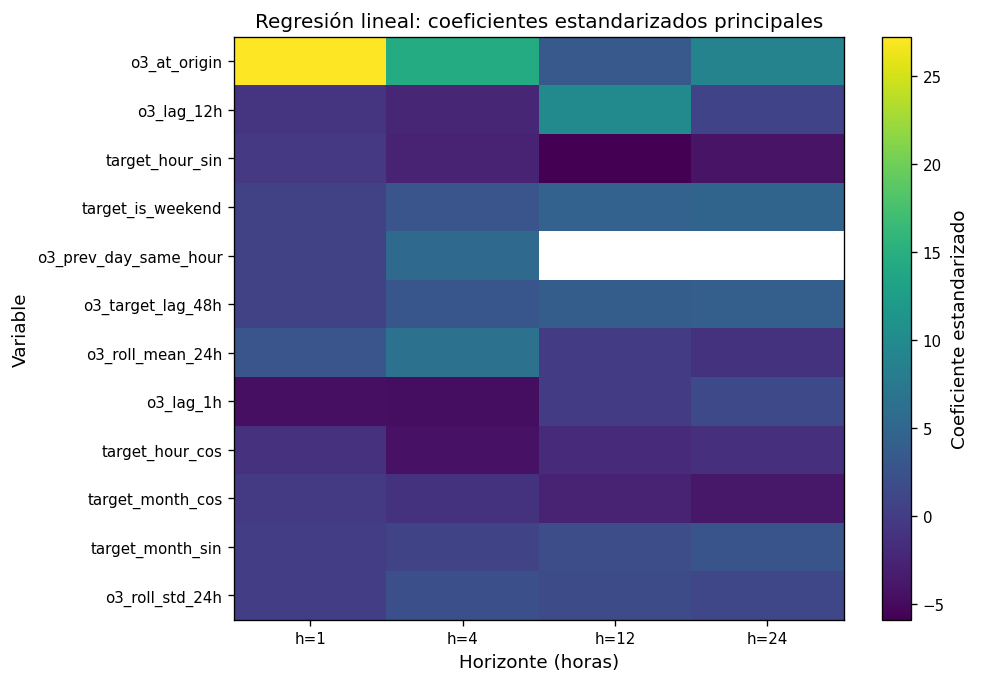

In [7]:
# Figura. Coeficientes principales de la regresión lineal.
linear_mean_abs = (
    linear_coefficients_df
    .groupby("feature", as_index=False)
    .agg(mean_abs=("importance_abs", "mean"))
    .sort_values("mean_abs", ascending=False)
)
selected_linear_features = linear_mean_abs.head(12)["feature"].tolist()

coef_pivot = (
    linear_coefficients_df
    .loc[linear_coefficients_df["feature"].isin(selected_linear_features)]
    .pivot_table(index="feature", columns="horizon", values="coefficient_standardized", aggfunc="mean")
    .loc[selected_linear_features]
)

fig, ax = plt.subplots(figsize=(8.5, 5.8))
im = ax.imshow(coef_pivot.values, aspect="auto")
ax.set_title("Regresión lineal: coeficientes estandarizados principales")
ax.set_xlabel("Horizonte (horas)")
ax.set_ylabel("Variable")
ax.set_xticks(range(len(coef_pivot.columns)))
ax.set_xticklabels([f"h={h}" for h in coef_pivot.columns])
ax.set_yticks(range(len(coef_pivot.index)))
ax.set_yticklabels(coef_pivot.index)
fig.colorbar(im, ax=ax, label="Coeficiente estandarizado")
fig.tight_layout()

linear_coefficients_figure_path = save_figure(
    fig,
    REPORTS_FIGURES_DIR / "xai_validation_linear_coefficients_heatmap.png",
)
plt.show()


## SHAP global para LightGBM y CatBoost

Para los modelos de *gradient boosting*, se calculan, a continuación, las contribuciones SHAP sobre el conjunto de validación. En LightGBM, utilizaremos las contribuciones nativas obtenidas mediante `pred_contrib=True`; en CatBoost emplearemos `get_feature_importance(type="ShapValues")`.

De esta manera obtendremos la media del valor absoluto de SHAP por variable,e s decir:

$$
I_j = \frac{1}{n}\sum_{i=1}^{n} |\phi_{i,j}|.
$$


In [8]:
shap_values_by_model_horizon: dict[tuple[str, int], np.ndarray] = {}
shap_samples_by_model_horizon: dict[tuple[str, int], pd.DataFrame] = {}

for model_id in ["lightgbm", "catboost"]:
    print("=" * 100)
    print(f"Calculando SHAP para {MODEL_REGISTRY[model_id]['display_name']}")

    for horizon in HORIZONS:
        print("-" * 100)
        print(f"Modelo={model_id} - horizonte={horizon} h")

        feature_columns = get_feature_columns(horizon)
        X_val_sample, y_val_sample, metadata_sample = validation_sample_for_xai(
            datasets_by_horizon[horizon],
            feature_columns,
            sample_size=SHAP_SAMPLE_SIZE,
        )

        model, source_info = load_xai_model(model_id, horizon)
        shap_values = compute_boosting_shap_values(
            model_id=model_id,
            model=model,
            X=X_val_sample,
            model_source=source_info["model_source"],
        )

        if shap_values.shape != X_val_sample.shape:
            raise ValueError(
                f"La matriz SHAP de {model_id}, h={horizon} tiene forma {shap_values.shape}, "
                f"pero X tiene forma {X_val_sample.shape}."
            )

        shap_values_by_model_horizon[(model_id, horizon)] = shap_values
        shap_samples_by_model_horizon[(model_id, horizon)] = X_val_sample

        model_source_rows.append(
            {
                "model": model_id,
                "model_display": MODEL_REGISTRY[model_id]["display_name"],
                "horizon": horizon,
                "technique": MODEL_REGISTRY[model_id]["technique"],
                "model_source": source_info["model_source"],
                "model_path": source_info["model_path"],
                "n_validation_used": len(X_val_sample),
            }
        )

        mean_abs_shap = np.mean(np.abs(shap_values), axis=0)

        for feature, importance_value in zip(feature_columns, mean_abs_shap):
            feature_importance_rows.append(
                {
                    "model": model_id,
                    "model_display": MODEL_REGISTRY[model_id]["display_name"],
                    "horizon": horizon,
                    "feature": feature,
                    "family": feature_family(feature),
                    "importance_abs": float(importance_value),
                    "importance_type": "mean_abs_shap",
                    "model_source": source_info["model_source"],
                    "model_path": source_info["model_path"],
                    "n_validation_used": len(X_val_sample),
                }
            )

        print(
            f"SHAP calculado con {len(X_val_sample):,} observaciones de validación. "
            f"Fuente del modelo: {source_info['model_source']}"
        )

print("Cálculo SHAP finalizado.")


Calculando SHAP para LightGBM
----------------------------------------------------------------------------------------------------
Modelo=lightgbm - horizonte=1 h
SHAP calculado con 2,500 observaciones de validación. Fuente del modelo: cqr_median_q0.50
----------------------------------------------------------------------------------------------------
Modelo=lightgbm - horizonte=4 h
SHAP calculado con 2,500 observaciones de validación. Fuente del modelo: cqr_median_q0.50
----------------------------------------------------------------------------------------------------
Modelo=lightgbm - horizonte=12 h
SHAP calculado con 2,500 observaciones de validación. Fuente del modelo: cqr_median_q0.50
----------------------------------------------------------------------------------------------------
Modelo=lightgbm - horizonte=24 h
SHAP calculado con 2,500 observaciones de validación. Fuente del modelo: cqr_median_q0.50
Calculando SHAP para CatBoost
----------------------------------------------

## Importancia por variable y por familia

Para poder comparar modelos auditados con técnicas distintas, normalizaremos las importancias para cada pareja modelo-horizonte. Cabe recordar que esta normalización no convierte la explicabilidad en una puntuación concreta que permita seleccionar o descartar modelos.


In [9]:
xai_feature_importance_df = pd.DataFrame(feature_importance_rows)

if xai_feature_importance_df.empty:
    raise ValueError("No se han generado importancias explicativas.")

xai_feature_importance_df = normalize_importance(xai_feature_importance_df)
xai_feature_importance_df["model_order"] = xai_feature_importance_df["model"].map(MODEL_ORDER_MAP)
xai_feature_importance_df["family_order"] = xai_feature_importance_df["family"].map({family: i for i, family in enumerate(FAMILY_ORDER)})

xai_feature_importance_df = xai_feature_importance_df.sort_values(
    ["model_order", "horizon", "importance_relative"],
    ascending=[True, True, False],
).reset_index(drop=True)

xai_family_importance_df = (
    xai_feature_importance_df
    .groupby(["model", "model_display", "horizon", "family"], as_index=False)
    .agg(
        importance_abs=("importance_abs", "sum"),
        importance_relative=("importance_relative", "sum"),
        n_features=("feature", "nunique"),
    )
)
xai_family_importance_df["model_order"] = xai_family_importance_df["model"].map(MODEL_ORDER_MAP)
xai_family_importance_df["family_order"] = xai_family_importance_df["family"].map({family: i for i, family in enumerate(FAMILY_ORDER)})
xai_family_importance_df = xai_family_importance_df.sort_values(
    ["model_order", "horizon", "family_order"]
).reset_index(drop=True)

xai_top_features_df = (
    xai_feature_importance_df
    .sort_values(["model_order", "horizon", "importance_relative"], ascending=[True, True, False])
    .groupby(["model", "horizon"], group_keys=False)
    .head(8)
    .reset_index(drop=True)
)

print("Ránking de variables por modelo y horizonte:")
display(xai_top_features_df[[
    "model_display",
    "horizon",
    "feature",
    "family",
    "importance_relative",
    "importance_type",
    "model_source",
]])

print("Importancia agregada por familias:")
display(xai_family_importance_df[[
    "model_display",
    "horizon",
    "family",
    "importance_relative",
    "n_features",
]])


Ránking de variables por modelo y horizonte:


,model_display,horizon,feature,family,importance_relative,importance_type,model_source
0,Modelo base ingenuo estacional,1,o3_prev_day_same_hour,Persistencia diaria,1.0000,regla_explicita,seasonal_naive_rule
1,Modelo base ingenuo estacional,4,o3_prev_day_same_hour,Persistencia diaria,1.0000,regla_explicita,seasonal_naive_rule
2,Modelo base ingenuo estacional,12,o3_prev_day_same_hour,Persistencia diaria,1.0000,regla_explicita,seasonal_naive_rule
3,Modelo base ingenuo estacional,24,o3_prev_day_same_hour,Persistencia diaria,1.0000,regla_explicita,seasonal_naive_rule
4,Regresión lineal,1,o3_at_origin,Memoria reciente,0.6348,abs_coeficiente_estandarizado,cqr_median_q0.50
5,Regresión lineal,1,o3_lag_1h,Memoria reciente,0.1036,abs_coeficiente_estandarizado,cqr_median_q0.50
6,Regresión lineal,1,o3_roll_mean_24h,Ventanas móviles,0.0673,abs_coeficiente_estandarizado,cqr_median_q0.50
7,Regresión lineal,1,o3_roll_mean_6h,Ventanas móviles,0.0483,abs_coeficiente_estandarizado,cqr_median_q0.50
8,Regresión lineal,1,target_hour_cos,Calendario horario,0.0261,abs_coeficiente_estandarizado,cqr_median_q0.50
9,Regresión lineal,1,o3_lag_12h,Memoria reciente,0.0197,abs_coeficiente_estandarizado,cqr_median_q0.50


Importancia agregada por familias:


,model_display,horizon,family,importance_relative,n_features
0,Modelo base ingenuo estacional,1,Persistencia diaria,1.0000,1
1,Modelo base ingenuo estacional,4,Persistencia diaria,1.0000,1
2,Modelo base ingenuo estacional,12,Persistencia diaria,1.0000,1
3,Modelo base ingenuo estacional,24,Persistencia diaria,1.0000,1
4,Regresión lineal,1,Memoria reciente,0.7688,6
5,Regresión lineal,1,Persistencia diaria,0.0245,2
6,Regresión lineal,1,Ventanas móviles,0.1381,5
7,Regresión lineal,1,Calendario horario,0.0342,2
8,Regresión lineal,1,Calendario mensual,0.0066,2
9,Regresión lineal,1,Calendario semanal,0.0260,3


Figura guardada: c:\trabajo_github\reports\figures\xai_validation_family_importance_heatmap.png


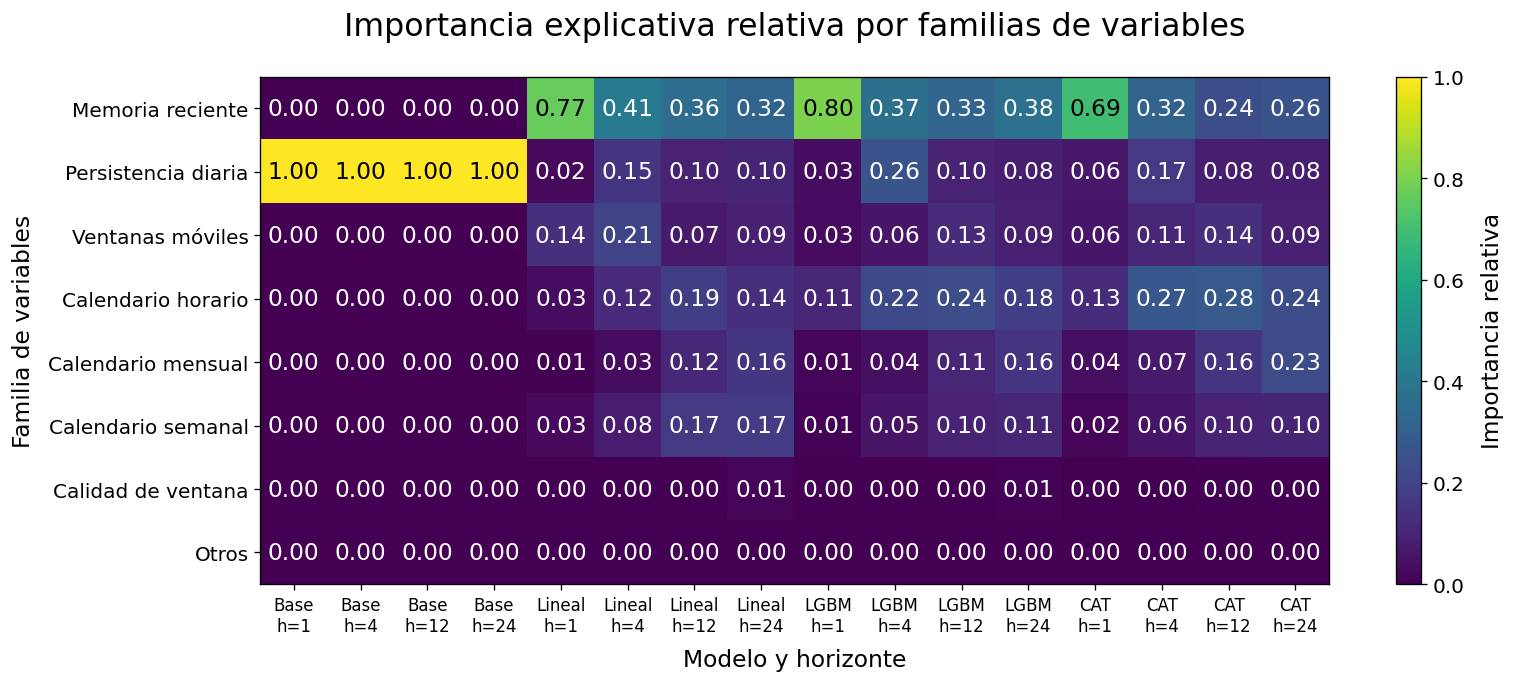

In [10]:
from matplotlib import patheffects as pe
import numpy as np
import pandas as pd

# Mapa de calor de importancia relativa por familias.
heatmap_df = xai_family_importance_df.copy()

heatmap_df["column"] = heatmap_df.apply(
    lambda row: f"{MODEL_REGISTRY[row['model']]['short_name']}\nh={int(row['horizon'])}",
    axis=1,
)

family_heatmap = (
    heatmap_df
    .pivot_table(
        index="family",
        columns="column",
        values="importance_relative",
        aggfunc="sum",
    )
    .reindex(FAMILY_ORDER)
)

# Orden de columnas por modelo y horizonte.
ordered_columns = []

for model_id in MODEL_ORDER:
    short_name = MODEL_REGISTRY[model_id]["short_name"]

    for horizon in HORIZONS:
        column = f"{short_name}\nh={horizon}"

        if column in family_heatmap.columns:
            ordered_columns.append(column)

family_heatmap = family_heatmap.loc[:, ordered_columns].fillna(0.0)

# Figura.
fig, ax = plt.subplots(figsize=(13.5, 5.8))

cmap = plt.get_cmap("viridis")
norm = plt.Normalize(
    vmin=0,
    vmax=max(0.01, family_heatmap.values.max()),
)

image = ax.imshow(
    family_heatmap.values,
    aspect="auto",
    cmap=cmap,
    norm=norm,
)

ax.set_title(
    "Importancia explicativa relativa por familias de variables",
    fontsize=19,
    pad=25,
)

ax.set_xlabel("Modelo y horizonte", fontsize=14, labelpad=8)
ax.set_ylabel("Familia de variables", fontsize=14, labelpad=8)

ax.set_xticks(np.arange(family_heatmap.shape[1]))
ax.set_xticklabels(family_heatmap.columns, rotation=0)

ax.set_yticks(np.arange(family_heatmap.shape[0]))
ax.set_yticklabels(family_heatmap.index)

ax.tick_params(axis="y", labelsize=12)
ax.tick_params(axis="x", labelsize=10)

for row_idx in range(family_heatmap.shape[0]):
    for col_idx in range(family_heatmap.shape[1]):
        value = family_heatmap.iat[row_idx, col_idx]

        if pd.isna(value):
            continue

        rgba = cmap(norm(value))
        r, g, b, _ = rgba

        luminance = 0.299 * r + 0.587 * g + 0.114 * b

        text_color = "black" if luminance > 0.55 else "white"

        ax.text(
            col_idx,
            row_idx,
            f"{value:.2f}",
            ha="center",
            va="center",
            fontsize=14,
            color=text_color,
        )

colorbar = fig.colorbar(image, ax=ax)
colorbar.set_label("Importancia relativa", fontsize=14, labelpad=10)
colorbar.ax.tick_params(labelsize=12)

fig.tight_layout()

family_heatmap_path = save_figure(
    fig,
    REPORTS_FIGURES_DIR / "xai_validation_family_importance_heatmap.png",
)

plt.show()

Figura guardada: c:\trabajo_github\reports\figures\xai_validation_top_features_by_model.png


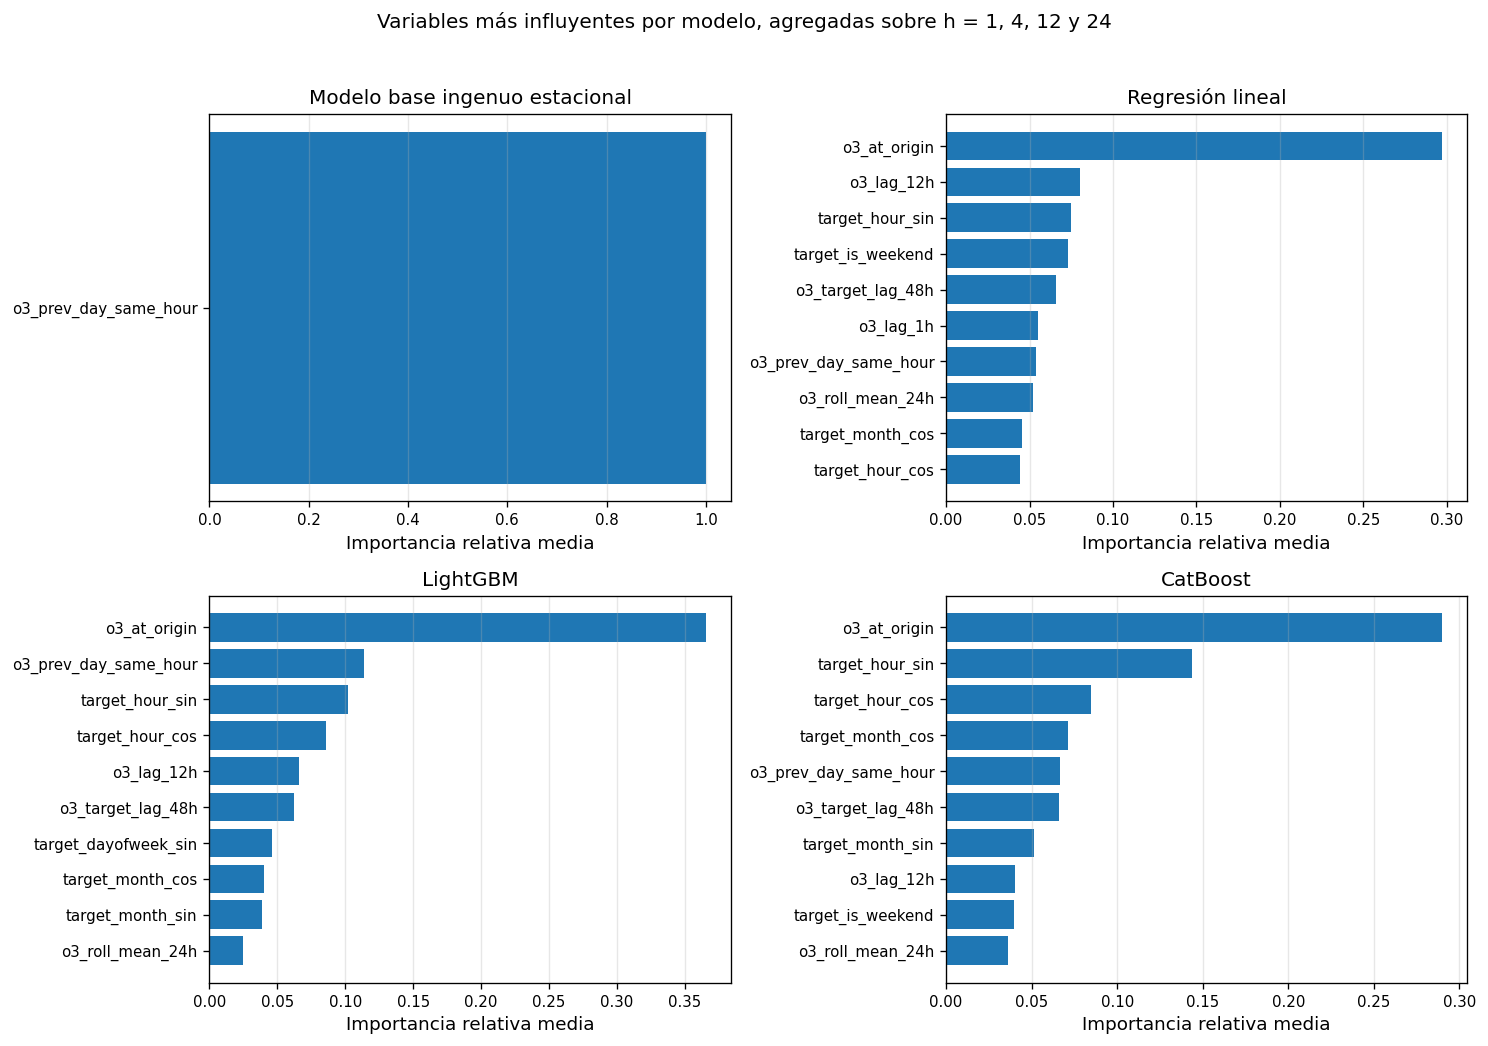

In [11]:
# Figura que muestr alas variables más dominantes agregadas según el modelo.
aggregated_feature_importance = (
    xai_feature_importance_df
    .groupby(["model", "model_display", "feature", "family"], as_index=False)
    .agg(mean_relative_importance=("importance_relative", "mean"))
)
aggregated_feature_importance["model_order"] = aggregated_feature_importance["model"].map(MODEL_ORDER_MAP)
aggregated_feature_importance = aggregated_feature_importance.sort_values(
    ["model_order", "mean_relative_importance"],
    ascending=[True, False],
)

fig, axes = plt.subplots(2, 2, figsize=(12.5, 8.5))
axes = axes.ravel()

for ax, model_id in zip(axes, MODEL_ORDER):
    subset = aggregated_feature_importance.loc[aggregated_feature_importance["model"] == model_id].head(10)
    subset = subset.iloc[::-1]
    ax.barh(subset["feature"], subset["mean_relative_importance"])
    ax.set_title(MODEL_REGISTRY[model_id]["display_name"])
    ax.set_xlabel("Importancia relativa media")
    ax.grid(True, axis="x", alpha=0.3)

fig.suptitle("Variables más influyentes por modelo, agregadas sobre h = 1, 4, 12 y 24", y=1.02)
fig.tight_layout()

top_features_figure_path = save_figure(
    fig,
    REPORTS_FIGURES_DIR / "xai_validation_top_features_by_model.png",
)
plt.show()


## Auditoría explicativa de los candidatos

La siguiente tabla resume la auditoría explicativa en función de si los modelos resultan admisibles o no. 

- Admisible: las variables dominantes no tienen una importancia alarmante y explican el funcionamiento del modelo razonablemente
- Admisible, pero con cautela: se detecta la presencia de alguna señal que podría ser alarmante; el modelo podría ser admisible pero deberá estarse al tanto de dichas limitaciones estructurales
- No admisible: el comportamiento del modelo resulta inexplicable o toma decisiones en base a una sola variable.

In [12]:
def comma_join(items: Iterable[str], max_items: int = 5) -> str:
    items = list(items)[:max_items]
    return ", ".join(items)


def top_families_for_model(model_id: str, max_items: int = 4) -> list[str]:
    subset = xai_family_importance_df.loc[xai_family_importance_df["model"] == model_id]
    ranked = (
        subset
        .groupby("family", as_index=False)
        .agg(mean_relative_importance=("importance_relative", "mean"))
        .sort_values("mean_relative_importance", ascending=False)
    )
    return [
        f"{row.family} ({row.mean_relative_importance:.2f})"
        for row in ranked.head(max_items).itertuples(index=False)
    ]


def top_features_for_model(model_id: str, max_items: int = 5) -> list[str]:
    subset = xai_feature_importance_df.loc[xai_feature_importance_df["model"] == model_id]
    ranked = (
        subset
        .groupby("feature", as_index=False)
        .agg(mean_relative_importance=("importance_relative", "mean"))
        .sort_values("mean_relative_importance", ascending=False)
    )
    return [
        f"{row.feature} ({row.mean_relative_importance:.2f})"
        for row in ranked.head(max_items).itertuples(index=False)
    ]


def family_mean_share(model_id: str, family: str) -> float:
    subset = xai_family_importance_df.loc[
        (xai_family_importance_df["model"] == model_id)
        & (xai_family_importance_df["family"] == family)
    ]
    if subset.empty:
        return 0.0
    return float(subset["importance_relative"].mean())


admissibility_rows: list[dict[str, Any]] = []

for model_id in MODEL_ORDER:
    display_name = MODEL_REGISTRY[model_id]["display_name"]
    technique = MODEL_REGISTRY[model_id]["technique"]
    top_families = top_families_for_model(model_id)
    top_features = top_features_for_model(model_id)

    cautions: list[str] = []
    coherence = "Alta"
    suggested_verdict = "Admisible"

    if model_id == "baseline_seasonal_naive":
        coherence = "Alta respecto a la persistencia diaria"
        cautions.append("Regla no adaptativa.")
        suggested_verdict = "Admisible como referencia"

    elif model_id == "linear_regression":
        coherence = "Razonable si predominan la memoria temporal, la persistencia diaria o las variables de calendario"
        cautions.append("Modelo lineal; tiene, pues, una capacidad limitada para capturar interacciones no lineales.")
        suggested_verdict = "Admisible con cautelas"

    elif model_id in {"lightgbm", "catboost"}:
        coherence = "Razonable si SHAP prioriza la memoria temporal, la persistencia diaria, las ventanas y las variables calendario"
        cautions.append("SHAP es descriptivo: no establece causalidad.")

    quality_share = family_mean_share(model_id, "Calidad de la ventana")
    if quality_share >= 0.15:
        cautions.append(
            f"La familia 'Calidad de la ventana' alcanza una importancia media de {quality_share:.2f}; conviene revisarla."
        )
        if suggested_verdict == "Admisible":
            suggested_verdict = "Admisible con cautelas"

    top_family_names = [item.split(" (")[0] for item in top_families]
    expected_families = {
        "Memoria reciente",
        "Persistencia diaria",
        "Ventanas móviles",
        "Calendario horario",
        "Calendario mensual",
    }
    if not set(top_family_names).intersection(expected_families):
        cautions.append("Las familias dominantes no coinciden con las principales señales temporales esperadas.")
        suggested_verdict = "Admisible con cautelas"

    admissibility_rows.append(
        {
            "model": model_id,
            "modelo": display_name,
            "tecnica_explicativa": technique,
            "familias_dominantes": comma_join(top_families, max_items=4),
            "variables_dominantes": comma_join(top_features, max_items=5),
            "coherencia_con_eda": coherence,
            "cautelas": " ".join(cautions) if cautions else "No se detectan cautelas automáticas relevantes.",
            "dictamen_sugerido": suggested_verdict,
        }
    )

xai_admissibility_summary_df = pd.DataFrame(admissibility_rows)
display(xai_admissibility_summary_df)


,model,modelo,tecnica_explicativa,familias_dominantes,variables_dominantes,coherencia_con_eda,cautelas,dictamen_sugerido
0,baseline_seasonal_naive,Modelo base ingenuo estacional,Regla explícita,Persistencia diaria (1.00),o3_prev_day_same_hour (1.00),Alta respecto a la persistencia diaria,Regla no adaptativa.,Admisible como referencia
1,linear_regression,Regresión lineal,Coeficientes estandarizados,"Memoria reciente (0.47), Ventanas móviles (0.1...","o3_at_origin (0.30), o3_lag_12h (0.08), target...","Razonable si predominan la memoria temporal, l...","Modelo lineal; tiene, pues, una capacidad limi...",Admisible con cautelas
2,lightgbm,LightGBM,SHAP global,"Memoria reciente (0.47), Calendario horario (0...","o3_at_origin (0.37), o3_prev_day_same_hour (0....",Razonable si SHAP prioriza la memoria temporal...,SHAP es descriptivo: no establece causalidad.,Admisible
3,catboost,CatBoost,SHAP global,"Memoria reciente (0.38), Calendario horario (0...","o3_at_origin (0.29), target_hour_sin (0.14), t...",Razonable si SHAP prioriza la memoria temporal...,SHAP es descriptivo: no establece causalidad.,Admisible


## Guardado de tablas

A continuación, guardaremos las tablas que hemos ido generando.


In [13]:
model_sources_df = pd.DataFrame(model_source_rows).sort_values(
    ["model", "horizon"],
    key=lambda s: s.map(MODEL_ORDER_MAP) if s.name == "model" else s,
).reset_index(drop=True)

# Tabla amplia para consultar todas las variables.
feature_importance_path = save_dataframe_csv(
    xai_feature_importance_df.drop(columns=["model_order", "family_order"], errors="ignore"),
    REPORTS_TABLES_DIR / "xai_validation_feature_importance.csv",
    index=False,
)

family_importance_path = save_dataframe_csv(
    xai_family_importance_df.drop(columns=["model_order", "family_order"], errors="ignore"),
    REPORTS_TABLES_DIR / "xai_validation_family_importance.csv",
    index=False,
)

top_features_path = save_dataframe_csv(
    xai_top_features_df.drop(columns=["model_order", "family_order"], errors="ignore"),
    REPORTS_TABLES_DIR / "xai_validation_top_features.csv",
    index=False,
)

linear_coefficients_path = save_dataframe_csv(
    linear_coefficients_df.drop(columns=["model_order", "family_order"], errors="ignore"),
    REPORTS_TABLES_DIR / "xai_validation_linear_coefficients.csv",
    index=False,
)

admissibility_path = save_dataframe_csv(
    xai_admissibility_summary_df,
    REPORTS_TABLES_DIR / "xai_validation_admissibility_summary.csv",
    index=False,
)

model_sources_path = save_dataframe_csv(
    model_sources_df,
    REPORTS_TABLES_DIR / "xai_validation_model_sources.csv",
    index=False,
)

# Matriz lista para la memoria o anexos.
family_heatmap_csv_path = save_dataframe_csv(
    family_heatmap.reset_index(),
    REPORTS_TABLES_DIR / "xai_validation_family_importance_heatmap_matrix.csv",
    index=False,
)


Tabla guardada: c:\trabajo_github\reports\tables\xai_validation_feature_importance.csv
Tabla guardada: c:\trabajo_github\reports\tables\xai_validation_family_importance.csv
Tabla guardada: c:\trabajo_github\reports\tables\xai_validation_top_features.csv
Tabla guardada: c:\trabajo_github\reports\tables\xai_validation_linear_coefficients.csv
Tabla guardada: c:\trabajo_github\reports\tables\xai_validation_admissibility_summary.csv
Tabla guardada: c:\trabajo_github\reports\tables\xai_validation_model_sources.csv
Tabla guardada: c:\trabajo_github\reports\tables\xai_validation_family_importance_heatmap_matrix.csv


## Figuras SHAP complementarias

Para complementar el mapa de calor por familias y el gráfico de variables dominantes por modelo, generaremos una figura de dispersión SHAP para el horizonte de 24 horas en LightGBM y CatBoost, que podría resultar útil si se desea ilustrar la relación entre el valor de la variable y la contribución SHAP.

Figura guardada: c:\trabajo_github\reports\figures\xai_validation_shap_scatter_lightgbm_h24.png


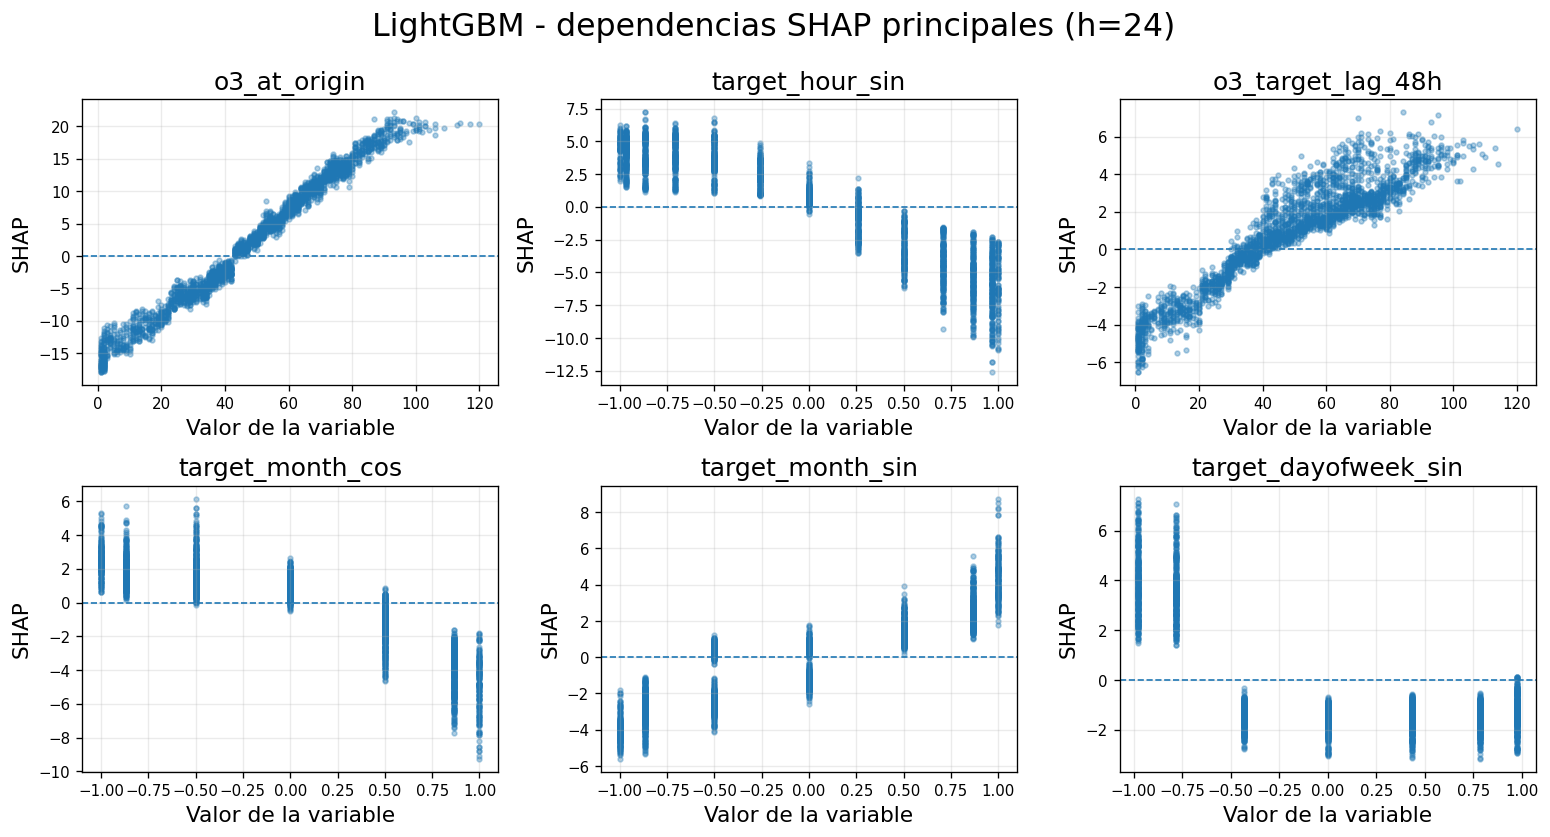

Figura guardada: c:\trabajo_github\reports\figures\xai_validation_shap_scatter_catboost_h24.png


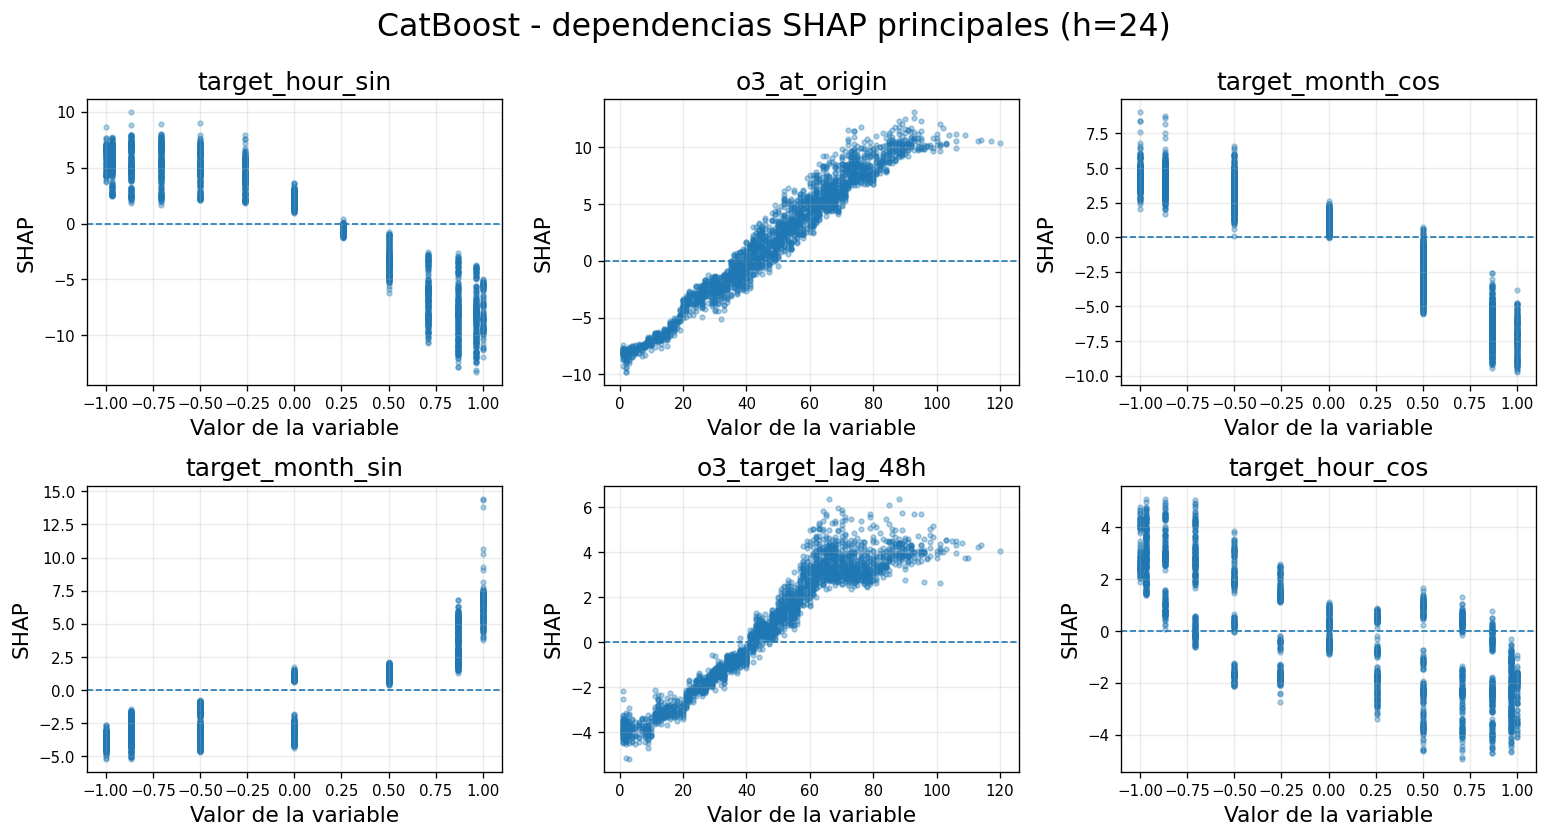

In [14]:
GENERATE_SHAP_SCATTER_FIGURES = True
SHAP_SCATTER_HORIZON = 24
MAX_SCATTER_FEATURES = 6

if GENERATE_SHAP_SCATTER_FIGURES:
    for model_id in ["lightgbm", "catboost"]:
        key = (model_id, SHAP_SCATTER_HORIZON)
        if key not in shap_values_by_model_horizon:
            warnings.warn(f"No hay valores SHAP para {model_id}, h={SHAP_SCATTER_HORIZON}.")
            continue

        X_sample = shap_samples_by_model_horizon[key]
        shap_values = shap_values_by_model_horizon[key]
        mean_abs = np.mean(np.abs(shap_values), axis=0)
        top_feature_indices = np.argsort(mean_abs)[::-1][:MAX_SCATTER_FEATURES]

        fig, axes = plt.subplots(2, 3, figsize=(13, 7))
        axes = axes.ravel()

        for ax, feature_idx in zip(axes, top_feature_indices):
            feature = X_sample.columns[feature_idx]
            ax.scatter(X_sample.iloc[:, feature_idx], shap_values[:, feature_idx], s=8, alpha=0.35)
            ax.axhline(0, linestyle="--", linewidth=1)
            ax.set_title(feature, fontsize=15)
            ax.set_xlabel("Valor de la variable", fontsize=13)
            ax.set_ylabel("SHAP", fontsize=13)
            ax.grid(True, alpha=0.25)

        fig.suptitle(
            f"{MODEL_REGISTRY[model_id]['display_name']} - dependencias SHAP principales (h={SHAP_SCATTER_HORIZON})",
            y=0.99, fontsize = 19,
        )
        fig.tight_layout()
        save_figure(
            fig,
            REPORTS_FIGURES_DIR / f"xai_validation_shap_scatter_{model_id}_h{SHAP_SCATTER_HORIZON:02d}.png",
        )
        plt.show()


## Explicabilidad local en episodios representativos

El análisis efectuado resume el comportamiento global de los modelos candidatos. Para complementarlo, en esta sección se generarán explicaciones locales en formato waterfall para dos predicciones concretas del conjunto de validación de 2024: un episodio de concentración elevada y otro de concentración reducida de O3.

Para evitar una selección manual de ejemplos favorables, los casos se eligirán mediante una regla automatizada: se tomarán observaciones del decil superior e inferior de la variable objetivo y, dentro de cada grupo, se seleccionará el caso cuyo error absoluto esté más próximo al error mediano de dicho grupo.

In [15]:
# Funciones auxiliares

def extract_feature_shap_array_and_base(
    raw_values: np.ndarray,
    n_features: int,
    n_objects: int,
    preferred_output_index: int - None = None,
) -> tuple[np.ndarray, np.ndarray]:
    arr = np.asarray(raw_values, dtype=float)
    output_index = 0 if preferred_output_index is None else preferred_output_index

    if arr.ndim == 2:
        if arr.shape[1] == n_features + 1:
            return arr[:, :-1], arr[:, -1]
        if arr.shape[1] == n_features:
            return arr, np.zeros(arr.shape[0])

    if arr.ndim == 3:
        if arr.shape[0] == n_objects and arr.shape[1] == n_features + 1:
            output_index = min(output_index, arr.shape[2] - 1)
            return arr[:, :-1, output_index], arr[:, -1, output_index]

        if arr.shape[0] == n_objects and arr.shape[2] == n_features + 1:
            output_index = min(output_index, arr.shape[1] - 1)
            return arr[:, output_index, :-1], arr[:, output_index, -1]

        if arr.shape[1] == n_objects and arr.shape[2] == n_features + 1:
            output_index = min(output_index, arr.shape[0] - 1)
            return arr[output_index, :, :-1], arr[output_index, :, -1]

    raise ValueError(
        f"No se pudo interpretar la forma de SHAP local: {arr.shape} "
        f"para {n_objects} observaciones y {n_features} variables."
    )

def compute_boosting_shap_values_with_base(
    model_id: str,
    model: Any,
    X: pd.DataFrame,
    model_source: str,
) -> tuple[np.ndarray, np.ndarray]:
    if model_id == "lightgbm":
        try:
            raw_values = model.predict(X, pred_contrib=True)
        except TypeError:
            raw_values = model.booster_.predict(X, pred_contrib=True)
        preferred_output_index = None

    elif model_id == "catboost":
        raw_values = model.get_feature_importance(Pool(X), type="ShapValues")
        preferred_output_index = 2 if "multiquantile" in model_source else None

    else:
        raise ValueError(f"La explicación local waterfall solo se ha implementado para modelos de gradient boosting, no para {model_id}.")

    return extract_feature_shap_array_and_base(
        raw_values,
        n_features=X.shape[1],
        n_objects=len(X),
        preferred_output_index=preferred_output_index,
    )

def predict_central_output(model_id: str, model: Any, X: pd.DataFrame, model_source: str) -> np.ndarray:
    try:
        raw_pred = model.predict(X)
    except Exception:
        if model_id == "catboost":
            raw_pred = model.predict(Pool(X))
        else:
            raise

    arr = np.asarray(raw_pred, dtype=float)

    if arr.ndim == 0:
        return np.repeat(float(arr), len(X))

    if arr.ndim == 1:
        return arr

    if arr.ndim == 2:
        if "multiquantile" in model_source:
            # CatBoost MultiQuantile puede devolver (n, salidas) o (salidas, n).
            if arr.shape[0] == len(X) and arr.shape[1] >= 3:
                return arr[:, 2]
            if arr.shape[1] == len(X) and arr.shape[0] >= 3:
                return arr[2, :]

        if arr.shape[0] == len(X) and arr.shape[1] == 1:
            return arr[:, 0]
        if arr.shape[1] == len(X) and arr.shape[0] == 1:
            return arr[0, :]
        if arr.shape[0] == len(X):
            return arr[:, -1]
        if arr.shape[1] == len(X):
            return arr[-1, :]

    raise ValueError(f"No se pudo interpretar la predicción del modelo: forma {arr.shape}.")

def select_representative_extreme_cases(
    validation_df: pd.DataFrame,
    y_pred: np.ndarray,
    high_quantile: float = 0.90,
    low_quantile: float = 0.10,
) -> pd.DataFrame:
    """Selecciona un episodio alto y uno bajo de concentración de O3 de forma automática."""
    candidates = validation_df[["origin_timestamp", "target_timestamp", "y"]].copy().reset_index(drop=True)
    candidates["row_position"] = np.arange(len(candidates))
    candidates["y_pred"] = np.asarray(y_pred, dtype=float)
    candidates["abs_error"] = (candidates["y"] - candidates["y_pred"]).abs()

    high_threshold = candidates["y"].quantile(high_quantile)
    low_threshold = candidates["y"].quantile(low_quantile)

    high_subset = candidates.loc[candidates["y"] >= high_threshold].copy()
    low_subset = candidates.loc[candidates["y"] <= low_threshold].copy()

    if high_subset.empty or low_subset.empty:
        raise ValueError("No se pudieron seleccionar episodios alto (o bajo) para la explicación local.")

    def pick_representative(subset: pd.DataFrame, case_type: str, threshold: float) -> pd.Series:
        median_error = subset["abs_error"].median()
        idx = (subset["abs_error"] - median_error).abs().idxmin()
        selected = subset.loc[idx].copy()
        selected["case_type"] = case_type
        selected["selection_threshold"] = threshold
        selected["selection_rule"] = (
            "observación del decil correspondiente cuyo error absoluto está más próximo al error mediano de ese decil"
        )
        return selected

    selected_cases = pd.DataFrame(
        [
            pick_representative(high_subset, "Concentración alta", high_threshold),
            pick_representative(low_subset, "Concentración baja", low_threshold),
        ]
    )

    return selected_cases.reset_index(drop=True)


def format_feature_value(value: Any) -> str:
    if pd.isna(value):
        return "NaN"
    try:
        value = float(value)
    except Exception:
        return str(value)

    if abs(value) >= 100:
        return f"{value:.1f}"
    if abs(value) >= 10:
        return f"{value:.2f}"
    if abs(value - round(value)) < 1e-9:
        return f"{value:.0f}"
    return f"{value:.3f}".rstrip("0").rstrip(".")


def build_waterfall_items(
    shap_values_row: np.ndarray,
    feature_values_row: pd.Series,
    feature_names: Sequence[str],
    max_display: int = 12,
) -> list[dict[str, Any]]:
    """Construimos la lista de las contribuciones que se mostrarán en el gráfico."""
    contributions = np.asarray(shap_values_row, dtype=float)
    order = np.argsort(np.abs(contributions))[::-1]

    if max_display >= len(feature_names):
        top_idx = order
        rest_idx = np.array([], dtype=int)
    else:
        top_idx = order[: max_display - 1]
        rest_idx = order[max_display - 1 :]

    items: list[dict[str, Any]] = []
    for idx in top_idx:
        feature = feature_names[idx]
        items.append(
            {
                "feature": feature,
                "feature_value": feature_values_row[feature],
                "label": f"{format_feature_value(feature_values_row[feature])} = {feature}",
                "contribution": float(contributions[idx]),
            }
        )

    if len(rest_idx) > 0:
        items.append(
            {
                "feature": "otras_variables",
                "feature_value": np.nan,
                "label": f"otras variables ({len(rest_idx)})",
                "contribution": float(contributions[rest_idx].sum()),
            }
        )

    return items

def plot_local_waterfall(
    ax: plt.Axes,
    items: list[dict[str, Any]],
    base_value: float,
    prediction_value: float,
    title: str,
    max_label_chars: int = 42,
) -> None:
    """Dibujamos la waterfall con matplotlib."""
    y_positions = np.arange(len(items))[::-1]
    cumulative = float(base_value)
    cumulative_points = [cumulative]

    for y_pos, item in zip(y_positions, items):
        contribution = float(item["contribution"])
        new_value = cumulative + contribution
        left = min(cumulative, new_value)
        width = abs(contribution)
        color = "#ff0051" if contribution >= 0 else "#008bfb"

        ax.barh(y_pos, width, left=left, height=0.72, color=color, alpha=0.90)

        text_x = new_value + (0.015 * max(1.0, abs(prediction_value - base_value)))
        ha = "left"
        if contribution < 0:
            text_x = new_value - (0.015 * max(1.0, abs(prediction_value - base_value)))
            ha = "right"
        ax.text(
            text_x,
            y_pos,
            f"{contribution:+.2f}",
            va="center",
            ha=ha,
            fontsize=10,
            color=color,
        )

        cumulative = new_value
        cumulative_points.append(cumulative)

    labels = []
    for item in items:
        label = str(item["label"])
        if len(label) > max_label_chars:
            label = label[: max_label_chars - 1] + "…"
        labels.append(label)

    ax.set_yticks(y_positions)

    # Etiquetas del eje Y: nombres de variables
    ax.set_yticklabels(labels, fontsize=11)

    # Valores de los ticks del eje X y del eje Y
    ax.tick_params(axis="x", which="major", labelsize=11)
    ax.tick_params(axis="y", which="major", labelsize=11)

    ax.axvline(base_value, linestyle="--", linewidth=1, color="0.4", alpha=0.75)
    ax.axvline(prediction_value, linestyle="-", linewidth=1.2, color="0.2", alpha=0.85)
    ax.grid(True, axis="x", alpha=0.25)

    ax.set_title(title, fontsize=13)

    # Texto del eje X: "Contribución acumulada..."
    ax.set_xlabel(
        r"Contribución acumulada a la predicción de $\mathrm{O}_3$ (µg/m³)",
        fontsize=12,
    )

    all_x = np.array(cumulative_points + [base_value, prediction_value], dtype=float)
    x_span = max(1.0, float(all_x.max() - all_x.min()))
    ax.set_xlim(all_x.min() - 0.12 * x_span, all_x.max() + 0.16 * x_span)
    # Pequeño desplazamiento horizontal para que el texto quede
    # justo a la derecha de la línea vertical
    xmin, xmax = ax.get_xlim()
    x_offset = 0.01 * (xmax - xmin)

    ax.text(
        base_value + x_offset,
        -0.30,
        f"E[f(X)] = {base_value:.2f}",
        ha="left",
        va="center",
        fontsize=8,
        color="0.35",
    )

    ax.text(
        prediction_value + x_offset,
        len(items) - 0.70,
        f"f(x) = {prediction_value:.2f}",
        ha="left",
        va="center",
        fontsize=8,
        color="0.25",
    )


Tabla guardada: c:\trabajo_github\reports\tables\xai_validation_local_cases_catboost_h24.csv
Tabla guardada: c:\trabajo_github\reports\tables\xai_validation_local_shap_contributions_catboost_h24.csv
Casos seleccionados para la explicación a nivel local:


,case_type,origin_timestamp,target_timestamp,target_timestamp_label,y,y_pred,pred_from_shap_sum,abs_error,selection_rule
0,Concentración elevada,2024-06-27 15:00:00,2024-06-28 15:00:00,28/06/2024 15:00,94.0000,76.4279,76.4279,17.5721,observación del tramo seleccionado cuyo error ...
1,Concentración reducida,2024-06-27 07:00:00,2024-06-28 07:00:00,28/06/2024 07:00,8.0000,22.2268,22.2268,14.2268,observación del tramo seleccionado cuyo error ...


Figura guardada: c:\trabajo_github\reports\figures\xai_validation_local_waterfall_catboost_h24.png


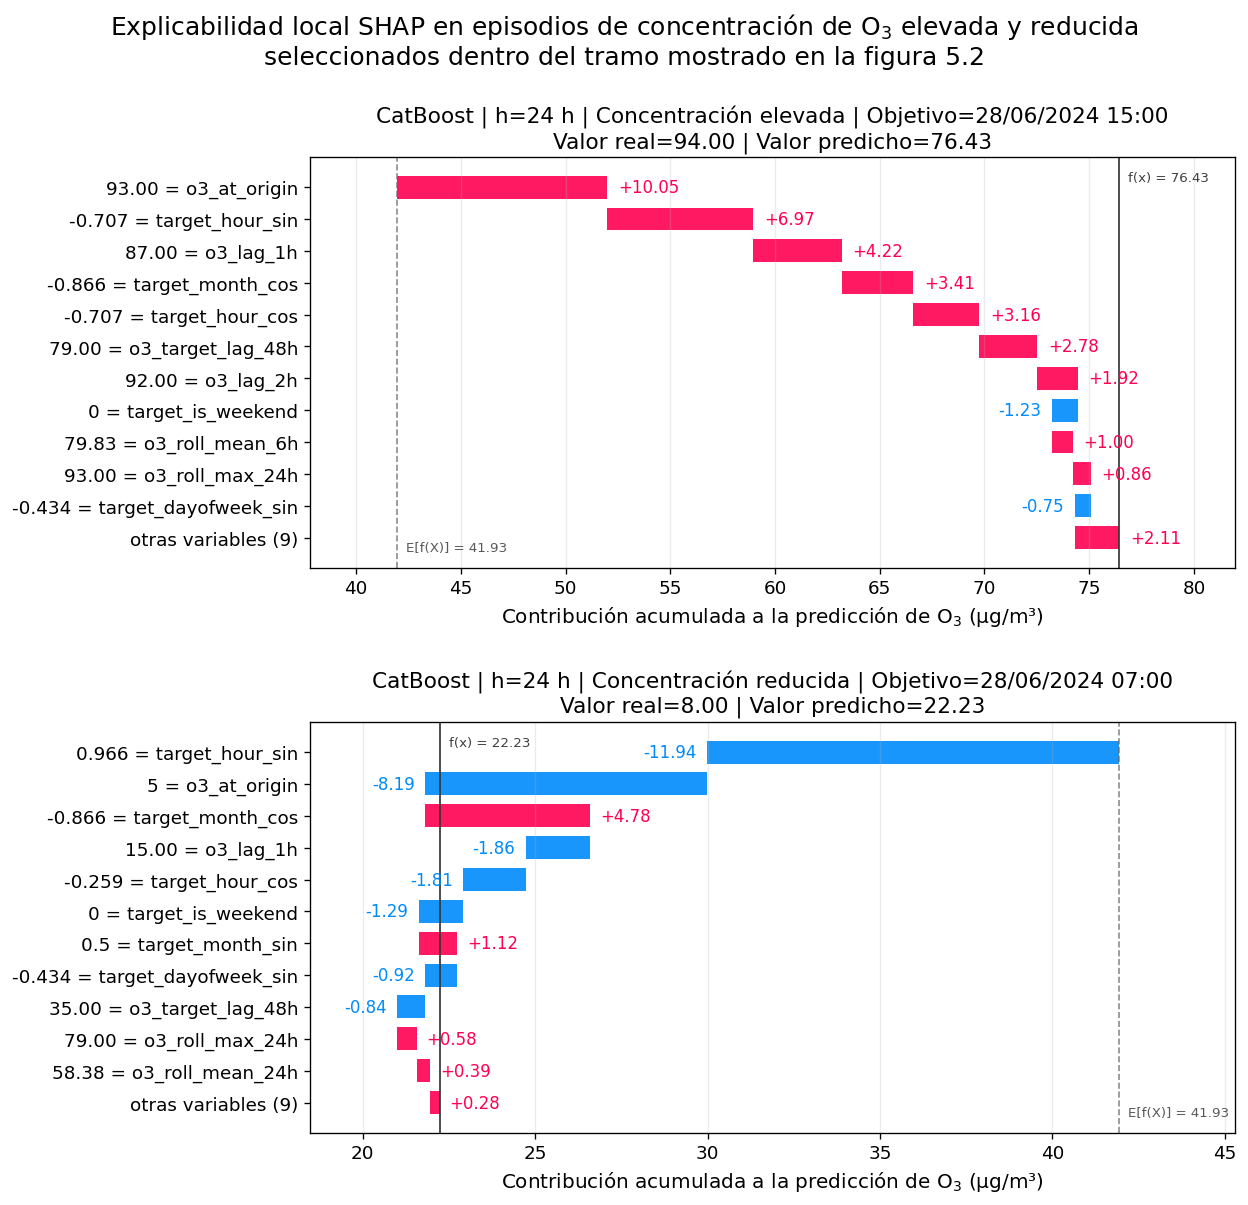

In [31]:
# Explicación a nivel local.

GENERATE_LOCAL_WATERFALL_FIGURE = True
LOCAL_EXPLANATION_MODEL = "catboost"
LOCAL_WATERFALL_HORIZON = 24
LOCAL_WATERFALL_MAX_DISPLAY = 12

LOCAL_FIGURE_5_2_START_TS = pd.Timestamp("2024-06-28 00:00:00")
LOCAL_FIGURE_5_2_END_TS = pd.Timestamp("2024-07-01 23:00:00")

LOCAL_MANUAL_TARGET_TIMESTAMPS = None
LOCAL_MANUAL_CASE_TYPES = ["Concentración elevada", "Concentración reducida"]

LOCAL_HIGH_CONCENTRATION_QUANTILE = 0.8
LOCAL_LOW_CONCENTRATION_QUANTILE = 0.5

local_waterfall_paths: list[Path] = []


def format_target_timestamp_for_title(timestamp: Any) -> str:
    """Formatea una fecha objetivo de forma compacta para el título del panel."""
    ts = pd.Timestamp(timestamp)
    return ts.strftime("%d/%m/%Y %H:%M")


def select_representative_concentration_cases_from_visual_window(
    validation_df: pd.DataFrame,
    y_pred: np.ndarray,
    visual_start: pd.Timestamp,
    visual_end: pd.Timestamp,
    manual_target_timestamps: list[str] | None = None,
    manual_case_types: list[str] | None = None,
    high_quantile: float = 0.90,
    low_quantile: float = 0.10,
) -> pd.DataFrame:
    """Selecciona un episodio de concentración elevada y otro reducida dentro del tramo especificado."""
    candidates = validation_df[["origin_timestamp", "target_timestamp", "y"]].copy().reset_index(drop=True)
    candidates["origin_timestamp"] = pd.to_datetime(candidates["origin_timestamp"])
    candidates["target_timestamp"] = pd.to_datetime(candidates["target_timestamp"])
    candidates["row_position"] = np.arange(len(candidates))
    candidates["y_pred"] = np.asarray(y_pred, dtype=float)
    candidates["abs_error"] = (candidates["y"] - candidates["y_pred"]).abs()

    visual_start = pd.Timestamp(visual_start)
    visual_end = pd.Timestamp(visual_end)

    visual_window = candidates.loc[
        (candidates["target_timestamp"] >= visual_start)
        & (candidates["target_timestamp"] <= visual_end)
    ].copy()

    if visual_window.empty:
        raise ValueError(
            "No hay observaciones en el tramo visual indicado. "
            "Revisa LOCAL_FIGURE_5_2_START_TS y LOCAL_FIGURE_5_2_END_TS."
        )

    if manual_target_timestamps is not None:
        if len(manual_target_timestamps) != 2:
            raise ValueError("LOCAL_MANUAL_TARGET_TIMESTAMPS debe contener exactamente dos fechas.")

        if manual_case_types is None:
            manual_case_types = ["Caso visual 1", "Caso visual 2"]

        if len(manual_case_types) != len(manual_target_timestamps):
            raise ValueError("LOCAL_MANUAL_CASE_TYPES debe tener la misma longitud que LOCAL_MANUAL_TARGET_TIMESTAMPS.")

        selected_rows = []
        for target_timestamp, case_type in zip(manual_target_timestamps, manual_case_types):
            requested_timestamp = pd.Timestamp(target_timestamp)

            if requested_timestamp < visual_start or requested_timestamp > visual_end:
                raise ValueError(
                    f"La fecha {requested_timestamp} está fuera del tramo "
                    f"{visual_start} → {visual_end}."
                )

            exact_match = visual_window.loc[
                visual_window["target_timestamp"] == requested_timestamp
            ]

            if exact_match.empty:
                idx = (visual_window["target_timestamp"] - requested_timestamp).abs().idxmin()
                selected = visual_window.loc[idx].copy()
                selected["selection_rule"] = (
                    f"observación más próxima a {requested_timestamp} dentro del tramo seleccionad"
                )
            else:
                selected = exact_match.iloc[0].copy()
                selected["selection_rule"] = "observación seleccionada manualmente dentro del tramo"

            selected["case_type"] = case_type
            selected["requested_target_timestamp"] = requested_timestamp
            selected_rows.append(selected)

        return pd.DataFrame(selected_rows).reset_index(drop=True)

    high_threshold = visual_window["y"].quantile(high_quantile)
    low_threshold = visual_window["y"].quantile(low_quantile)

    high_subset = visual_window.loc[visual_window["y"] >= high_threshold].copy()
    low_subset = visual_window.loc[visual_window["y"] <= low_threshold].copy()

    if high_subset.empty or low_subset.empty:
        raise ValueError("No se pudieron seleccionar episodios de concentración elevada o reducida dentro del tramo visual.")

    def pick_representative(subset: pd.DataFrame, case_type: str, threshold: float) -> pd.Series:
        median_error = subset["abs_error"].median()
        idx = (subset["abs_error"] - median_error).abs().idxmin()
        selected = subset.loc[idx].copy()
        selected["case_type"] = case_type
        selected["selection_threshold"] = threshold
        selected["selection_rule"] = (
            "observación del tramo seleccionado cuyo error absoluto está más próximo al error mediano"
        )
        return selected

    selected_cases = pd.DataFrame(
        [
            pick_representative(high_subset, "Concentración elevada", high_threshold),
            pick_representative(low_subset, "Concentración reducida", low_threshold),
        ]
    )

    return selected_cases.reset_index(drop=True)


if GENERATE_LOCAL_WATERFALL_FIGURE:
    if LOCAL_EXPLANATION_MODEL not in {"lightgbm", "catboost"}:
        raise ValueError("La explicación local waterfall está pensada para LightGBM o CatBoost.")

    model_id = LOCAL_EXPLANATION_MODEL
    horizon = LOCAL_WATERFALL_HORIZON
    feature_columns = get_feature_columns(horizon)

    validation_df = (
        datasets_by_horizon[horizon]
        .loc[datasets_by_horizon[horizon]["split"] == VALIDATION_SPLIT]
        .dropna(subset=["y"])
        .sort_values("target_timestamp")
        .reset_index(drop=True)
    )
    validation_df["origin_timestamp"] = pd.to_datetime(validation_df["origin_timestamp"])
    validation_df["target_timestamp"] = pd.to_datetime(validation_df["target_timestamp"])

    X_validation = validation_df.loc[:, feature_columns].copy()

    model, source_info = load_xai_model(model_id, horizon)
    y_pred_validation = predict_central_output(
        model_id=model_id,
        model=model,
        X=X_validation,
        model_source=source_info["model_source"],
    )

    selected_cases_df = select_representative_concentration_cases_from_visual_window(
        validation_df=validation_df,
        y_pred=y_pred_validation,
        visual_start=LOCAL_FIGURE_5_2_START_TS,
        visual_end=LOCAL_FIGURE_5_2_END_TS,
        manual_target_timestamps=LOCAL_MANUAL_TARGET_TIMESTAMPS,
        manual_case_types=LOCAL_MANUAL_CASE_TYPES,
        high_quantile=LOCAL_HIGH_CONCENTRATION_QUANTILE,
        low_quantile=LOCAL_LOW_CONCENTRATION_QUANTILE,
    )

    selected_positions = selected_cases_df["row_position"].astype(int).to_numpy()
    X_cases = X_validation.iloc[selected_positions].copy().reset_index(drop=True)

    local_shap_values, local_base_values = compute_boosting_shap_values_with_base(
        model_id=model_id,
        model=model,
        X=X_cases,
        model_source=source_info["model_source"],
    )
    local_pred_from_shap = local_base_values + local_shap_values.sum(axis=1)

    selected_cases_df = selected_cases_df.reset_index(drop=True)
    selected_cases_df["model"] = model_id
    selected_cases_df["model_display"] = MODEL_REGISTRY[model_id]["display_name"]
    selected_cases_df["horizon"] = horizon
    selected_cases_df["model_source"] = source_info["model_source"]
    selected_cases_df["model_path"] = source_info["model_path"]
    selected_cases_df["base_value"] = local_base_values
    selected_cases_df["pred_from_shap_sum"] = local_pred_from_shap

    if "requested_target_timestamp" in selected_cases_df.columns:
        selected_cases_df["requested_target_timestamp"] = selected_cases_df["requested_target_timestamp"].astype(str)

    selected_cases_df["target_timestamp_label"] = selected_cases_df["target_timestamp"].apply(format_target_timestamp_for_title)
    selected_cases_df["target_timestamp"] = selected_cases_df["target_timestamp"].astype(str)
    selected_cases_df["origin_timestamp"] = selected_cases_df["origin_timestamp"].astype(str)

    # Tabla detallada de las contribuciones locales.
    local_contribution_rows: list[dict[str, Any]] = []
    for case_idx, case_row in selected_cases_df.iterrows():
        for feature, feature_value, shap_value in zip(feature_columns, X_cases.iloc[case_idx], local_shap_values[case_idx]):
            local_contribution_rows.append(
                {
                    "case_type": case_row["case_type"],
                    "model": model_id,
                    "horizon": horizon,
                    "origin_timestamp": case_row["origin_timestamp"],
                    "target_timestamp": case_row["target_timestamp"],
                    "feature": feature,
                    "family": feature_family(feature),
                    "feature_value": feature_value,
                    "shap_value": shap_value,
                    "abs_shap_value": abs(shap_value),
                }
            )

    local_contributions_df = (
        pd.DataFrame(local_contribution_rows)
        .sort_values(["case_type", "abs_shap_value"], ascending=[True, False])
        .reset_index(drop=True)
    )

    local_explanations_path = save_dataframe_csv(
        selected_cases_df,
        REPORTS_TABLES_DIR / f"xai_validation_local_cases_{model_id}_h{horizon:02d}.csv",
        index=False,
    )
    local_contributions_path = save_dataframe_csv(
        local_contributions_df,
        REPORTS_TABLES_DIR / f"xai_validation_local_shap_contributions_{model_id}_h{horizon:02d}.csv",
        index=False,
    )

    print("Casos seleccionados para la explicación a nivel local:")
    display_columns = [
        "case_type",
        "origin_timestamp",
        "target_timestamp",
        "target_timestamp_label",
        "y",
        "y_pred",
        "pred_from_shap_sum",
        "abs_error",
        "selection_rule",
    ]

    if "requested_target_timestamp" in selected_cases_df.columns:
        display_columns.insert(3, "requested_target_timestamp")

    display(selected_cases_df[display_columns])

    # Figura conjunta: concentración elevada y concentración reducida.
    fig, axes = plt.subplots(
        nrows=len(selected_cases_df),
        ncols=1,
        figsize=(10.5, 5.0 * len(selected_cases_df)),
        squeeze=False,
    )
    axes = axes.ravel()

    for case_idx, case_row in selected_cases_df.iterrows():
        items = build_waterfall_items(
            shap_values_row=local_shap_values[case_idx],
            feature_values_row=X_cases.iloc[case_idx],
            feature_names=feature_columns,
            max_display=LOCAL_WATERFALL_MAX_DISPLAY,
        )
        title = (
            f"{MODEL_REGISTRY[model_id]['display_name']} | h={horizon} h | "
            f"{case_row['case_type']} | Objetivo={case_row['target_timestamp_label']}\n"
            f"Valor real={case_row['y']:.2f} | Valor predicho={case_row['y_pred']:.2f}"
        )
        plot_local_waterfall(
            ax=axes[case_idx],
            items=items,
            base_value=float(local_base_values[case_idx]),
            prediction_value=float(local_pred_from_shap[case_idx]),
            title=title,
        )

    fig.suptitle(
        r"Explicabilidad local SHAP en episodios de concentración de $\mathrm{O}_3$ elevada y reducida"
        "\n"
        r"seleccionados dentro del tramo mostrado en la figura 5.2",
        y=1,
        fontsize=15,
    )
    fig.tight_layout(
        h_pad=2.5,
    )

    local_waterfall_path = save_figure(
        fig,
        REPORTS_FIGURES_DIR / f"xai_validation_local_waterfall_{model_id}_h{horizon:02d}.png",
    )
    local_waterfall_paths.append(local_waterfall_path)
    plt.show()

## Comprobaciones finales

Se verifica que la auditoría se haya realizado únicamente sobre el conjunto de validación, que todos los modelos y horizontes cuenten con resultados explicativos y que se hayan guardado las tablas y figuras principales.


In [17]:
expected_model_horizon_pairs = {(model_id, horizon) for model_id in MODEL_ORDER for horizon in HORIZONS}
observed_feature_pairs = set(
    xai_feature_importance_df[["model", "horizon"]]
    .drop_duplicates()
    .itertuples(index=False, name=None)
)

missing_pairs = sorted(expected_model_horizon_pairs - observed_feature_pairs)
if missing_pairs:
    raise AssertionError(f"Faltan resultados explicativos para: {missing_pairs}")

observed_source_pairs = set(
    model_sources_df[["model", "horizon"]]
    .drop_duplicates()
    .itertuples(index=False, name=None)
)
missing_source_pairs = sorted(expected_model_horizon_pairs - observed_source_pairs)
if missing_source_pairs:
    raise AssertionError(f"Faltan fuentes de modelos para: {missing_source_pairs}")

for horizon, df in datasets_by_horizon.items():
    if VALIDATION_SPLIT not in set(df["split"].dropna().unique()):
        raise AssertionError(f"No existe conjunto de validación para h={horizon}.")

expected_table_paths = [
    feature_importance_path,
    family_importance_path,
    top_features_path,
    linear_coefficients_path,
    admissibility_path,
    model_sources_path,
    family_heatmap_csv_path,
]

for optional_table_name in ["local_explanations_path", "local_contributions_path"]:
    if optional_table_name in globals():
        expected_table_paths.append(globals()[optional_table_name])

expected_figure_paths = [
    family_heatmap_path,
    top_features_figure_path,
    linear_coefficients_figure_path,
]

if "local_waterfall_paths" in globals():
    expected_figure_paths.extend(local_waterfall_paths)
elif "local_waterfall_path" in globals():
    expected_figure_paths.append(local_waterfall_path)

missing_files = [path for path in expected_table_paths + expected_figure_paths if not Path(path).exists()]
if missing_files:
    raise FileNotFoundError(f"No se han generado los siguientes archivos esperados: {missing_files}")

final_check_df = pd.DataFrame(
    {
        "check": [
            "resultados_modelo_horizonte",
            "fuentes_modelo_horizonte",
            "solo_validacion_2024",
            "tablas_principales_guardadas",
            "figuras_principales_guardadas",
            "sin_puntuacion_xai_en_objetivo",
        ],
        "status": [
            "ok",
            "ok",
            "ok",
            "ok",
            "ok",
            "ok",
        ],
    }
)

display(final_check_df)

print("Auditoría explicativa completada correctamente.")
print("Tablas principales:")
for path in expected_table_paths:
    print(f"- {path}")
print("Figuras principales:")
for path in expected_figure_paths:
    print(f"- {path}")
print("Figuras complementarias:")
for path in SAVED_FIGURE_PATHS:
    if path not in expected_figure_paths:
        print(f"- {path}")


,check,status
0,resultados_modelo_horizonte,ok
1,fuentes_modelo_horizonte,ok
2,solo_validacion_2024,ok
3,tablas_principales_guardadas,ok
4,figuras_principales_guardadas,ok
5,sin_puntuacion_xai_en_objetivo,ok


Auditoría explicativa completada correctamente.
Tablas principales:
- c:\trabajo_github\reports\tables\xai_validation_feature_importance.csv
- c:\trabajo_github\reports\tables\xai_validation_family_importance.csv
- c:\trabajo_github\reports\tables\xai_validation_top_features.csv
- c:\trabajo_github\reports\tables\xai_validation_linear_coefficients.csv
- c:\trabajo_github\reports\tables\xai_validation_admissibility_summary.csv
- c:\trabajo_github\reports\tables\xai_validation_model_sources.csv
- c:\trabajo_github\reports\tables\xai_validation_family_importance_heatmap_matrix.csv
- c:\trabajo_github\reports\tables\xai_validation_local_cases_catboost_h24.csv
- c:\trabajo_github\reports\tables\xai_validation_local_shap_contributions_catboost_h24.csv
Figuras principales:
- c:\trabajo_github\reports\figures\xai_validation_family_importance_heatmap.png
- c:\trabajo_github\reports\figures\xai_validation_top_features_by_model.png
- c:\trabajo_github\reports\figures\xai_validation_linear_coeffic